# Heimdall narrative analysis

Ingest is **persisted** in `heimdall.db` (or your `DATABASE_URL`). Each API ingest upserts posts and outrage scores.

Committed version uses **PNG plots + simple metadata** (like Julia notebooks). Before pushing edits, run `python scripts/export_notebook_github.py` from the repo root.

```bash
pip install -e ".[notebook]"
```

Set `NARRATIVE_NAME` below (e.g. `midterms_2026`).

In [1]:
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from heimdall.analysis.duplicates import find_duplicate_text_clusters
from heimdall.analysis.loader import load_narrative_posts, load_narratives

# --- configure ---
NARRATIVE_NAME = "midterms_2026"  # or set NARRATIVE_ID = 3
NARRATIVE_ID = None
MIN_OUTRAGE = 0.0

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "heimdall.db").exists() and (PROJECT_ROOT.parent / "heimdall.db").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

import os

os.chdir(PROJECT_ROOT)
DATABASE_URL = f"sqlite:///{(PROJECT_ROOT / 'heimdall.db').resolve()}"

print("Database:", DATABASE_URL)

Database: sqlite:////Users/jackweekly/Desktop/Project Heimdall/heimdall.db


In [2]:
narratives = load_narratives(database_url=DATABASE_URL)
narratives

In [3]:
posts = load_narrative_posts(
    narrative_id=NARRATIVE_ID,
    narrative_name=NARRATIVE_NAME if NARRATIVE_ID is None else None,
    database_url=DATABASE_URL,
    min_outrage=MIN_OUTRAGE if MIN_OUTRAGE > 0 else None,
)
print(f"Posts loaded: {len(posts)}")
posts.head(10)

Posts loaded: 78


In [4]:
summary = {
    "narrative": posts["narrative_name"].iloc[0] if len(posts) else None,
    "posts": len(posts),
    "unique_authors": posts["author_id"].nunique(),
    "platforms": sorted(posts["platform"].dropna().unique().tolist()),
    "outrage_mean": float(round(posts["outrage_index"].mean(), 4))
    if posts["outrage_index"].notna().any()
    else None,
    "outrage_max": float(round(posts["outrage_index"].max(), 4))
    if posts["outrage_index"].notna().any()
    else None,
    "known_bots": int(posts["known_bot_label"].notna().sum()),
}
summary

{'narrative': 'midterms_2026',
 'posts': 78,
 'unique_authors': 70,
 'platforms': ['x'],
 'outrage_mean': 0.0211,
 'outrage_max': 0.148,
 'known_bots': 0}

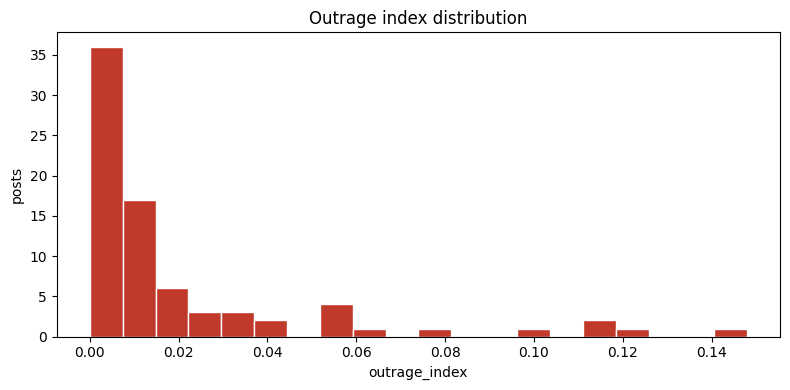

    post_id     author_handle  outrage_index sentiment_label                                                         text
69       54        @ruok_2day         0.1480        negative  VOTE DEM's OUT VOTE RED Down ballot Nov 3rd, 2026 Midter...
12      100   @IAMZORRO366723         0.1192        negative  I feel sorry for that SENILE COWARD FACIST NAZI PIG BONE...
72       57        @ACupOf_Ki         0.1144         neutral  🚨BREAKING:📷 President Trump to name Sidney Powell a DOJ ...
74       59      @1ReesieMula         0.1144         neutral  🚨BREAKING:📷 President Trump to name Sidney Powell a DOJ ...
54       67     @DavidDewar61         0.1034         neutral  Join 35th District State Representative Trump MAGA Red R...
14       82  @Retired_Infidel         0.0810         neutral  The X post from polling account highlights a May 27-28, ...
71       56  @TheDebriefing17         0.0628         neutral  🤔 TIMELINES PATTERNS 2026 MIDTERMS & FRAUD VITIATES EVER...
67       52   @patriot_h

In [5]:
scored = posts.dropna(subset=["outrage_index"])
if scored.empty:
    print("No outrage scores yet — re-ingest or check narrative id.")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(scored["outrage_index"], bins=20, color="#c0392b", edgecolor="white")
    ax.set_title("Outrage index distribution")
    ax.set_xlabel("outrage_index")
    ax.set_ylabel("posts")
    plt.tight_layout()
    plt.show()

    top = scored.nlargest(10, "outrage_index")[
        ["post_id", "author_handle", "outrage_index", "sentiment_label", "text"]
    ]
    # Text table renders on GitHub; avoid HTML display() from pandas
    print(top.to_string(max_colwidth=60))

In [6]:
clusters = find_duplicate_text_clusters(posts, min_posts=2)
print(f"Duplicate text clusters: {len(clusters)}")
for i, cluster in enumerate(clusters[:10], 1):
    print(f"\n--- cluster {i} ({cluster.count} posts, {len(cluster.author_ids)} authors) ---")
    print(cluster.sample_text)
    print("authors:", ", ".join(cluster.author_ids[:8]))

Duplicate text clusters: 4

--- cluster 1 (4 posts, 1 authors) ---
Accountability is the 2026 midterm issue. - TRUMP - corrupt DOJ/FBI - - Stop with all the gaslighting and Happy Talk 🤡 No one is being held accountable for - mounting federal debt - waste, fraud and abuse - mass deportations - Covid Injusti…
authors: 1518777787213041665

--- cluster 2 (3 posts, 1 authors) ---
Remember ! When you VOTE On Nov 3rd, 2026 Midterm Elections DEM Politicians Are STILL TRYING to Shut Down ICE
authors: 1981085696665227264

--- cluster 3 (2 posts, 2 authors) ---
These fascist/redneck judges might as well cut to the chase and block each and every Democrat throughout America of his/her voting rights, and/or stop the 2026 midterms entirely. I don't see what they're waiting for.
authors: 1777383147950280706, 1791965943431667712

--- cluster 4 (2 posts, 2 authors) ---
🚨BREAKING:📷 President Trump to name Sidney Powell a DOJ Special Attorney that he is calling his "Elections Czar" to investigate and pros

In [7]:
repeat_authors = (
    posts.groupby(["author_id", "author_handle"], dropna=False)
    .size()
    .reset_index(name="post_count")
    .sort_values("post_count", ascending=False)
)
repeat_authors.head(15)

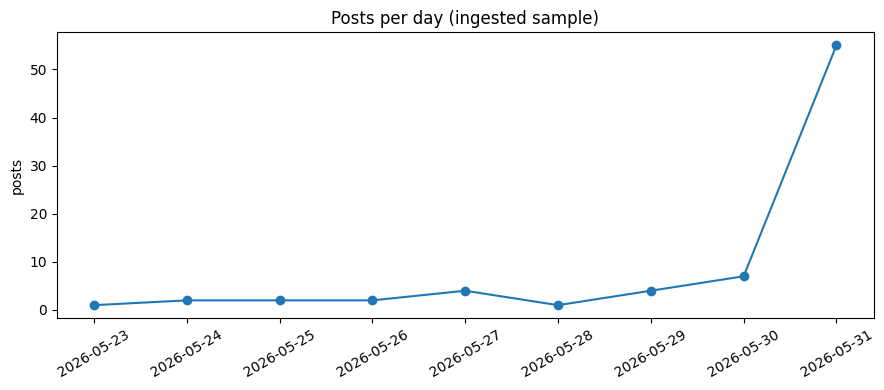

                posted_at  posts
2026-05-23 00:00:00+00:00      1
2026-05-24 00:00:00+00:00      2
2026-05-25 00:00:00+00:00      2
2026-05-26 00:00:00+00:00      2
2026-05-27 00:00:00+00:00      4
2026-05-28 00:00:00+00:00      1
2026-05-29 00:00:00+00:00      4
2026-05-30 00:00:00+00:00      7
2026-05-31 00:00:00+00:00     55


In [8]:
if not posts.empty and posts["posted_at"].notna().any():
    daily = (
        posts.set_index("posted_at")
        .resample("D")
        .size()
        .rename("posts")
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(daily["posted_at"], daily["posts"], marker="o")
    ax.set_title("Posts per day (ingested sample)")
    ax.set_ylabel("posts")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
    print(daily.to_string(index=False))